# Taller 4 — Expansión del análisis de retail

Este notebook continúa el análisis de `Taller_4_retail_analisis_completo.ipynb`. Aquel describía el negocio y segmentaba clientes; este lo expande con modelos predictivos, análisis regional y, más adelante, lealtad y pronóstico de ventas.

La lógica de análisis vive en el paquete `estadistica.retail`, así que el notebook y el dashboard usan exactamente las mismas funciones.

### Nota sobre los datos

Algunas secciones usan **datos simulados**, claramente etiquetados como tales, porque el dataset real no contiene esa información (por ejemplo encuestas de satisfacción). Es válido en un ejercicio académico para demostrar la técnica, siempre que no se presente lo simulado como real.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from estadistica import load_retail, retail

sns.set_theme(style="whitegrid")

df = retail.limpiar(load_retail())
dc = retail.solo_clientes(df)
print(f"Transacciones limpias: {df.shape[0]:,}  |  Clientes: {dc['CustomerID'].nunique():,}")


Transacciones limpias: 478,838  |  Clientes: 3,916


## 1. Predicción del valor del cliente

La pregunta de negocio es directa, ¿cuánto va a gastar cada cliente en el futuro? Saberlo permite priorizar a quién cuidar. Se usa una **regresión múltiple**, que predice una cantidad a partir de varias variables a la vez.


### El cuidado clave, evitar la circularidad

Hay una trampa fácil de cometer. Si se intenta predecir el gasto total de un cliente usando su frecuencia y su ticket promedio, el R² da casi 1, pero es un engaño, porque el gasto **es** frecuencia por ticket. El modelo no aprende nada, solo reconstruye una fórmula.

La forma correcta es separar el tiempo. Se calculan las variables con el comportamiento **pasado** y se predice el gasto **futuro**, dos períodos que no se solapan. Así el modelo predice de verdad. Se usa el 1 de septiembre de 2011 como corte, los meses anteriores son la entrada y los posteriores el objetivo.


In [2]:
feat = retail.dataset_valor_futuro(dc, fecha_corte="2011-09-01")

variables = ["Recencia", "Frecuencia", "Monetario", "Antiguedad", "Diversidad", "TicketMedio"]
volvieron = (feat["GastoFuturo"] > 0).mean() * 100

print(f"Clientes con actividad en el pasado: {len(feat):,}")
print(f"De esos, volvieron a comprar en el futuro: {volvieron:.0f}%")
feat[variables + ["GastoFuturo"]].describe().round(1)


Clientes con actividad en el pasado: 2,986
De esos, volvieron a comprar en el futuro: 59%


,Recencia,Frecuencia,Monetario,Antiguedad,Diversidad,TicketMedio,GastoFuturo
count,2986.0,2986.0,2986.0,2986.0,2986.0,2986.0,2986.0
mean,92.6,3.4,1408.1,176.7,48.3,368.5,834.1
std,76.6,5.4,4599.2,77.3,63.4,1483.3,4843.1
min,0.0,1.0,2.9,0.0,1.0,2.9,0.0
25%,27.0,1.0,246.8,118.0,13.0,163.9,0.0
50%,73.0,2.0,522.0,184.0,29.0,268.7,187.3
75%,146.0,4.0,1255.9,258.0,61.0,389.4,720.3
max,273.0,126.0,130537.2,273.0,1142.0,77183.6,168469.6


### Ajustar el modelo

Se entrena la regresión sobre una parte de los clientes y se evalúa en otra que el modelo no vio (división train/test). Así el R² de test mide la capacidad real de predecir, no de memorizar. Las variables se transforman con logaritmo para domar el sesgo.


In [3]:
resultado = retail.modelo_valor_futuro(feat)

print(f"R² en entrenamiento: {resultado['r2_train']:.3f}")
print(f"R² en test (lo que importa): {resultado['r2_test']:.3f}")


R² en entrenamiento: 0.256
R² en test (lo que importa): 0.273


El R² de test ronda **0.27**. Lejos del 0.99 falso de la versión circular, este número es honesto. Significa que el comportamiento pasado explica alrededor de un cuarto del gasto futuro. El resto depende de factores que no están en los datos, como necesidades puntuales, competencia o estacionalidad personal. Para predecir conducta humana con solo seis variables, capturar un cuarto es un resultado razonable y útil.


### Qué comportamientos anticipan el valor futuro

Los coeficientes estandarizados permiten comparar el peso de cada variable en igualdad de condiciones.


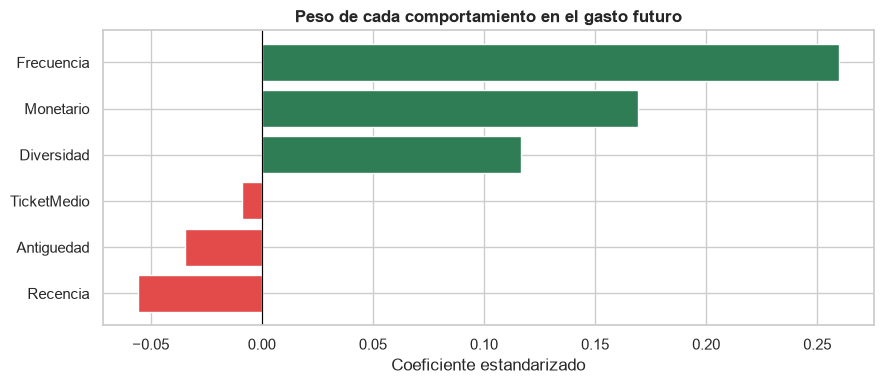

Recencia      -0.056
Antiguedad    -0.034
TicketMedio   -0.009
Diversidad     0.116
Monetario      0.169
Frecuencia     0.260
dtype: float64

In [4]:
coef = resultado["coef_estandarizado"].sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colores = ["#E24B4A" if v < 0 else "#2E7D55" for v in coef.values]
ax.barh(coef.index, coef.values, color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Peso de cada comportamiento en el gasto futuro", fontweight="bold")
ax.set_xlabel("Coeficiente estandarizado")
plt.tight_layout()
plt.show()

coef.round(3)


La **frecuencia** de compra pasada es el mejor predictor del gasto futuro, seguida del **monto**. Tiene sentido, quien compró seguido y mucho tiende a seguir comprando. La **recencia** pesa en contra, cuanto más tiempo lleva un cliente sin comprar, menos gasto futuro se espera. El ticket promedio y la antigüedad aportan poco una vez consideradas las demás. Conviene leer estos pesos con cautela, ya que las variables están correlacionadas entre sí.


### Qué tan bien predice, visto en un gráfico

Se comparan las predicciones con los valores reales en el conjunto de test. Si el modelo fuera perfecto, todos los puntos caerían sobre la diagonal.


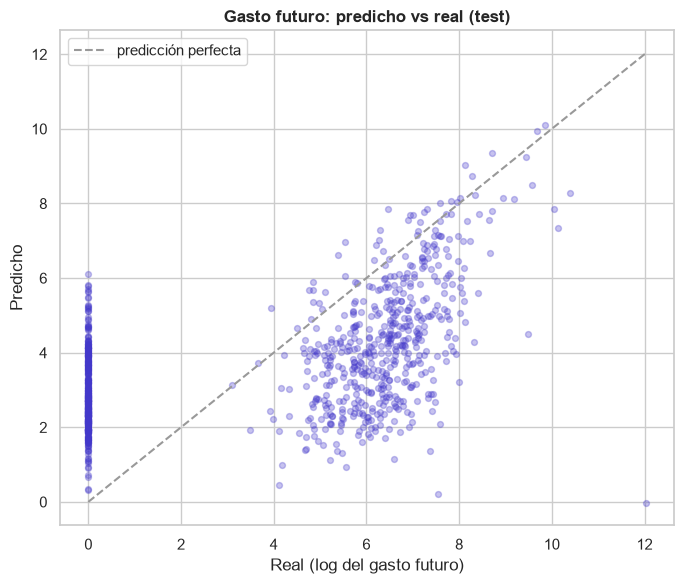

In [5]:
y_real = resultado["y_test"].values
y_pred = resultado["pred_test"].values

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_real, y_pred, alpha=0.3, color="#4338CA", s=18)
lim = max(y_real.max(), y_pred.max())
ax.plot([0, lim], [0, lim], "--", color="#999", label="predicción perfecta")
ax.set_title("Gasto futuro: predicho vs real (test)", fontweight="bold")
ax.set_xlabel("Real (log del gasto futuro)")
ax.set_ylabel("Predicho")
ax.legend()
plt.tight_layout()
plt.show()


La nube de puntos sigue la tendencia de la diagonal, el modelo acierta el patrón general aunque con dispersión. Se nota una franja de puntos en la base, que son los clientes que no volvieron a comprar, cuyo gasto futuro fue cero. Predecir ese abandono es justamente el tema de la siguiente etapa, la fuga de clientes.


### Conclusión de la sección

Se puede estimar el gasto futuro de un cliente a partir de su comportamiento pasado, con un poder predictivo modesto pero real. La frecuencia es la señal más fuerte, lo que refuerza una idea de negocio simple, mantener a los clientes comprando seguido es lo que más asegura su valor futuro. El modelo, hecho con cuidado para no caer en la circularidad, deja una base sólida para priorizar clientes y enlaza con la predicción de fuga que viene a continuación.


## 2. Predicción de la fuga de clientes (churn)

Si el modelo de valor predice cuánto gastará un cliente, este predice algo más urgente, si se va a ir. Saber con anticipación quién está por dejar de comprar permite actuar antes de perderlo. Es un problema de clasificación, sí o no, así que se usa una **regresión logística**, que en lugar de una cantidad devuelve una probabilidad.


### Definir la fuga sin trampa

Se define la fuga aprovechando el mismo corte temporal de la sección anterior. Un cliente está en fuga si **no volvió a comprar** en el período futuro. Las variables de entrada son las del pasado, así que, igual que antes, no hay circularidad, se predice el futuro con información que existía antes de ese futuro.


In [6]:
feat = retail.dataset_valor_futuro(dc, fecha_corte="2011-09-01")
resultado_churn = retail.modelo_churn(feat)

print(f"Tasa de fuga (no volvieron a comprar): {resultado_churn['tasa_churn']*100:.0f}%")
print(f"AUC en test: {resultado_churn['auc']:.3f}")
print(f"Aciertos (accuracy): {resultado_churn['accuracy']*100:.0f}%")


Tasa de fuga (no volvieron a comprar): 41%
AUC en test: 0.741
Aciertos (accuracy): 68%


El modelo logra un **AUC de 0.74**. El AUC mide qué tan bien separa a los que se van de los que se quedan, donde 0.5 sería puro azar y 1 perfecto. Un 0.74 es un resultado sólido y honesto, distingue bien sin caer en el sobreajuste sospechoso que daría una definición tramposa.


### Qué empuja a un cliente a irse


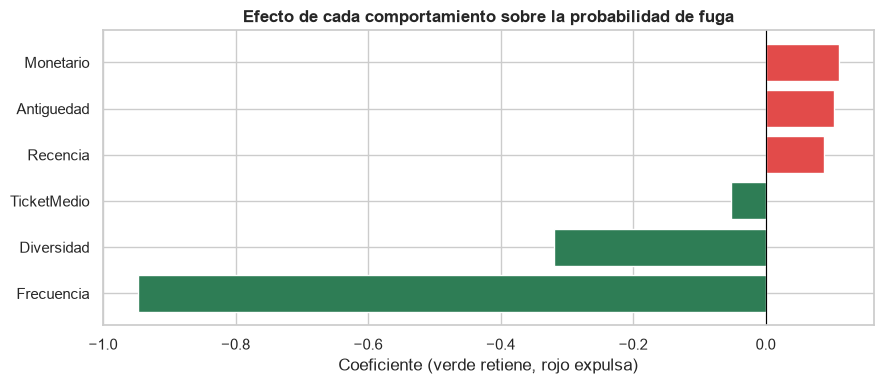

Frecuencia    -0.948
Diversidad    -0.319
TicketMedio   -0.052
Recencia       0.087
Antiguedad     0.104
Monetario      0.111
dtype: float64

In [7]:
coef = resultado_churn["coef"].sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colores = ["#E24B4A" if v > 0 else "#2E7D55" for v in coef.values]
ax.barh(coef.index, coef.values, color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Efecto de cada comportamiento sobre la probabilidad de fuga", fontweight="bold")
ax.set_xlabel("Coeficiente (verde retiene, rojo expulsa)")
plt.tight_layout()
plt.show()

coef.round(3)


La **frecuencia** es, por lejos, el mayor escudo contra la fuga, su coeficiente negativo fuerte indica que cuantas más veces compró un cliente, menos probable es que se vaya. La diversidad también retiene. En cambio, la recencia y la antigüedad empujan levemente hacia la fuga. El mensaje de negocio es claro, lograr que un cliente compre seguido es la mejor defensa contra perderlo.


### La curva ROC

La curva ROC resume el desempeño del modelo. Cuanto más se despega de la diagonal hacia la esquina superior izquierda, mejor distingue entre clientes que se van y que se quedan.


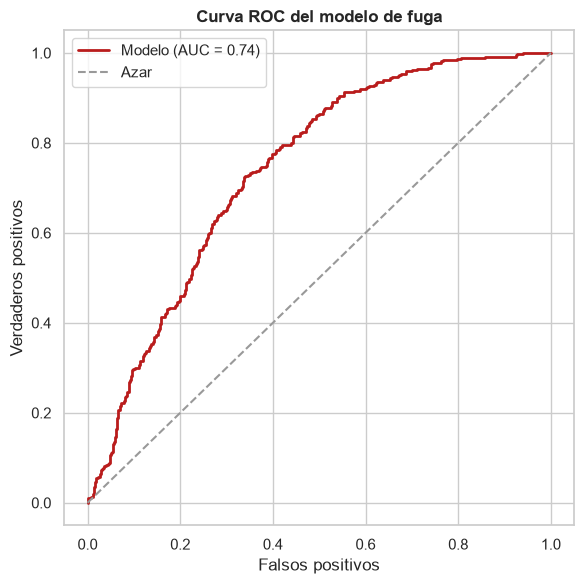

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(resultado_churn["fpr"], resultado_churn["tpr"], color="#B91C1C", linewidth=2,
        label=f"Modelo (AUC = {resultado_churn['auc']:.2f})")
ax.plot([0, 1], [0, 1], "--", color="#999", label="Azar")
ax.set_title("Curva ROC del modelo de fuga", fontweight="bold")
ax.set_xlabel("Falsos positivos")
ax.set_ylabel("Verdaderos positivos")
ax.legend()
plt.tight_layout()
plt.show()


### La salida accionable, clientes valiosos en riesgo

El modelo asigna a cada cliente una probabilidad de fuga. Cruzando esa probabilidad con su gasto pasado se obtiene la lista más útil para el negocio, los clientes valiosos que están por irse, justo donde una campaña de retención rinde más.


In [9]:
en_riesgo = resultado_churn["feat"]
valiosos_en_riesgo = (
    en_riesgo[en_riesgo["prob_churn"] >= 0.7]
    .sort_values("Monetario", ascending=False)
    [["CustomerID", "prob_churn", "Recencia", "Frecuencia", "Monetario"]]
    .head(10)
)
print("Top 10 clientes valiosos en riesgo de fuga:")
valiosos_en_riesgo.round(2)


Top 10 clientes valiosos en riesgo de fuga:


,CustomerID,prob_churn,Recencia,Frecuencia,Monetario
0,12346,0.79,225,1,77183.60
2874,18087,0.77,190,1,3202.92
179,13135,0.74,96,1,3096.00
2152,16754,0.76,272,1,2002.40
1294,15171,0.71,231,1,1289.50
2898,18133,0.74,112,1,931.50
2870,18080,0.75,142,1,841.50
987,14603,0.74,174,1,660.00
1448,15442,0.73,148,1,594.00
259,13270,0.78,266,1,590.00


### Conclusión de la sección

La regresión logística predice la fuga con buen desempeño y, sobre todo, entrega una lista priorizada de a quién retener. Confirma además la lección que venía apareciendo, la frecuencia de compra es el factor central, tanto para el valor futuro como para evitar la fuga. Las dos secciones juntas dan una vista completa de cada cliente, cuánto vale y qué riesgo hay de perderlo.


## 3. Mercados internacionales

Hasta aquí el análisis se concentró en el Reino Unido, que es el 85% del negocio. Pero el otro 15% son ventas a 37 países, y vale la pena ver qué hay ahí. A diferencia de sus secciones vecinas, esta no usa modelos, es un análisis descriptivo regional con datos reales.

Para que tenga sentido se descartan los países con muy pocos clientes, quedándose con los que tienen al menos diez.


In [10]:
df_global = retail.limpiar(load_retail(), solo_uk=False)
paises = retail.metricas_pais(df_global, min_clientes=10)
fuera = paises[paises["Country"] != "United Kingdom"]

print(f"Países con datos suficientes (sin UK): {len(fuera)}")
print(f"Ingresos fuera de UK: £{fuera['ingresos'].sum():,.0f}")
fuera[["Country", "ingresos", "clientes", "ticket_medio", "ingreso_por_cliente"]].round(0)


Países con datos suficientes (sin UK): 10
Ingresos fuera de UK: £637,887


,Country,ingresos,clientes,ticket_medio,ingreso_por_cliente
14,Germany,205381.0,94,464.0,2185.0
13,France,184493.0,87,483.0,2121.0
31,Spain,55707.0,30,633.0,1857.0
33,Switzerland,53066.0,21,1061.0,2527.0
3,Belgium,36927.0,25,377.0,1477.0
25,Norway,32455.0,10,1014.0,3245.0
27,Portugal,26951.0,19,539.0,1418.0
12,Finland,18345.0,12,459.0,1529.0
19,Italy,15820.0,14,452.0,1130.0
1,Austria,8743.0,11,514.0,795.0


### Dos tipos de mercado

El gráfico cruza la cantidad de clientes de cada país con cuánto gasta cada uno en promedio. Esa combinación separa dos perfiles muy distintos de mercado.


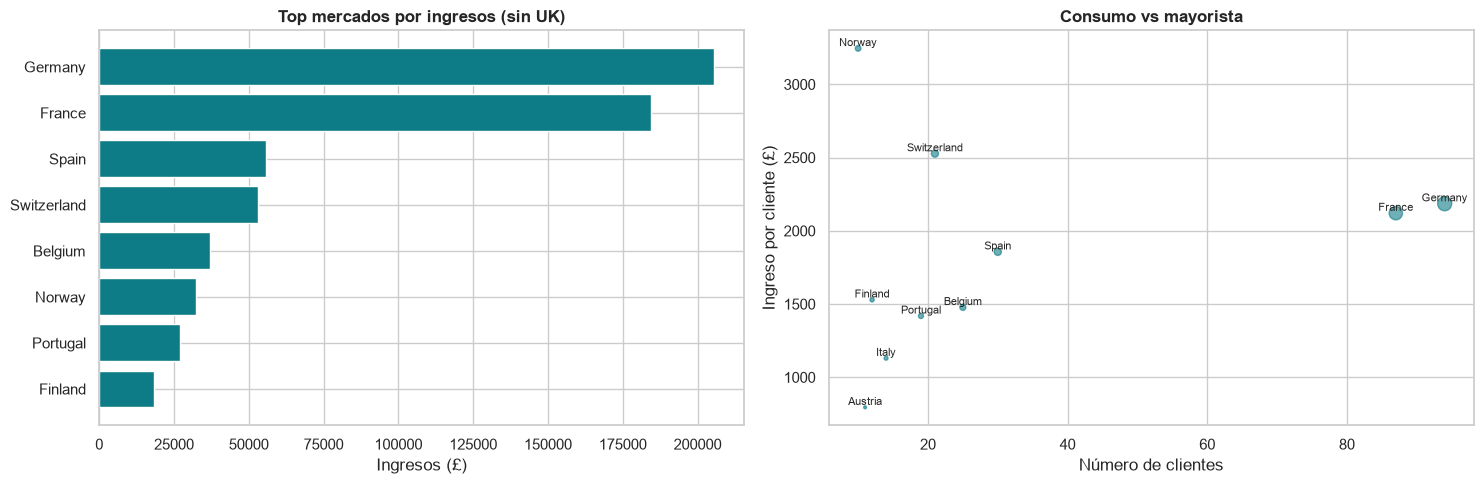

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top = fuera.head(8)
axes[0].barh(top["Country"][::-1], top["ingresos"][::-1], color="#0E7C86")
axes[0].set_title("Top mercados por ingresos (sin UK)", fontweight="bold")
axes[0].set_xlabel("Ingresos (£)")

axes[1].scatter(fuera["clientes"], fuera["ingreso_por_cliente"], s=fuera["ingresos"]/2000,
                color="#0E7C86", alpha=0.6)
for _, r in fuera.iterrows():
    axes[1].annotate(r["Country"], (r["clientes"], r["ingreso_por_cliente"]),
                     fontsize=8, ha="center", va="bottom")
axes[1].set_title("Consumo vs mayorista", fontweight="bold")
axes[1].set_xlabel("Número de clientes")
axes[1].set_ylabel("Ingreso por cliente (£)")

plt.tight_layout()
plt.show()


El gráfico de la derecha revela los dos perfiles. Arriba a la izquierda, pocos clientes pero con un gasto por cliente altísimo, aparecen mercados de perfil **mayorista** como Noruega y Suiza, donde unos pocos compradores grandes mueven casi todo. Abajo a la derecha, con muchos clientes y gasto más moderado, están los mercados de **consumo** como Alemania y Francia.

La lección para el negocio es que no hay una sola forma de crecer afuera. A los mercados de consumo conviene atacarlos con marketing masivo, mientras que a los mayoristas se los cuida con relaciones comerciales directas y precios por volumen, igual que al nicho mayorista que ya se había detectado dentro del Reino Unido.


### Cada país compra distinto

Una pregunta natural para expandirse es si conviene ofrecer el mismo catálogo en todos lados. Se contrasta con una prueba de chi-cuadrado si el país y los productos elegidos son independientes.


In [12]:
from scipy import stats

top_prod = df_global.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(15).index
paises = ["Germany", "France", "EIRE"]
sub = df_global[(df_global["Country"].isin(paises)) & (df_global["Description"].isin(top_prod))]
chi2, p_val, _, _ = stats.chi2_contingency(pd.crosstab(sub["Description"], sub["Country"]))

print(f"Chi-cuadrado, país vs producto: chi2={chi2:.0f}  p={p_val:.1e}")
print("Conclusión:", "cada país compra productos distintos" if p_val < 0.05 else "mismo surtido")


Chi-cuadrado, país vs producto: chi2=234  p=2.5e-35
Conclusión: cada país compra productos distintos


El p-valor es minúsculo, así que se confirma, **cada país compra productos distintos**. Esto descarta la idea de un catálogo único y abre la puerta a la localización, adaptar la oferta y las recomendaciones a cada mercado.


In [13]:
# Productos distintivos de un país, lo que sobre-consume frente al promedio
top_de, distintivos_de = retail.perfil_pais(df_global, "Germany")

print("Productos que Alemania compra mucho más que el promedio global:")
distintivos_de.round(1)


Productos que Alemania compra mucho más que el promedio global:


Description
PACK OF 12 RED APPLE TISSUES      17.6
WOODLAND SMALL BLUE FELT HEART    14.5
WOODLAND SMALL PINK FELT HEART    13.8
WOODLAND  STICKERS                13.1
BLUE OWL SOFT TOY                 12.7
APRON APPLE DELIGHT               12.2
PENCIL CASE LIFE IS BEAUTIFUL     12.2
STOOL HOME SWEET HOME             12.1
Name: Quantity, dtype: float64

El índice de especialización muestra qué productos sobresalen en cada mercado. Esos son los que conviene destacar y promocionar localmente, en lugar de replicar la vidriera del Reino Unido. Junto con la detección de clientes internacionales de alto valor, como Irlanda con un gasto por cliente altísimo, el análisis por país deja de ser un mapa descriptivo y se vuelve una guía de expansión, qué vender en cada lugar y dónde priorizar.


## 4. Lealtad de clientes con NPS

> **Nota, datos simulados.** El dataset de transacciones no incluye encuestas de satisfacción, así que el NPS no se puede calcular con datos reales. En esta sección se **simulan** las respuestas de la encuesta, calibradas según el comportamiento de cada cliente, para demostrar cómo se construye y se interpreta el indicador. Los números no son reales, son una simulación didáctica.

El NPS, o Net Promoter Score, mide la lealtad preguntando del 0 al 10 qué tan probable es que el cliente recomiende la tienda. Quienes responden 9 o 10 son promotores, 7 u 8 pasivos, y de 0 a 6 detractores. El NPS final es el porcentaje de promotores menos el de detractores, y va de -100 a 100.


In [14]:
rfm = retail.segmentar(retail.calcular_rfm(dc), 4)
nps_df = retail.nps_simulado(rfm, semilla=42)
nps_global = retail.calcular_nps(nps_df)

print(f"NPS global (simulado): {nps_global:+.0f}")
print(f"Promotores: {(nps_df['nps_cat']=='Promotor').mean()*100:.0f}%")
print(f"Pasivos:    {(nps_df['nps_cat']=='Pasivo').mean()*100:.0f}%")
print(f"Detractores:{(nps_df['nps_cat']=='Detractor').mean()*100:.0f}%")


NPS global (simulado): -7
Promotores: 26%
Pasivos:    42%
Detractores:33%


### NPS por segmento

La gracia de cruzar el NPS con la segmentación es que muestra dónde está la lealtad y dónde el descontento.


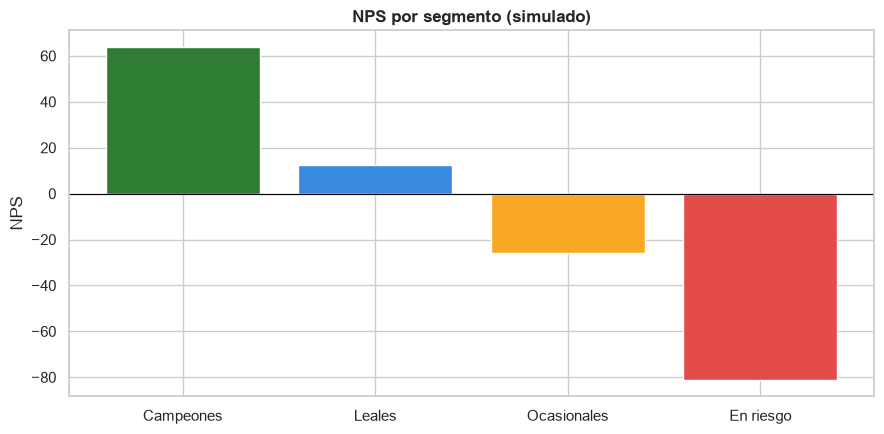

{'Campeones': 63.81278538812785,
 'Leales': 12.32876712328767,
 'Ocasionales': -25.83222370173102,
 'En riesgo': -81.12820512820514}

In [15]:
orden = ["Campeones", "Leales", "Ocasionales", "En riesgo"]
colores = {"Campeones": "#2E7D32", "Leales": "#378ADD", "Ocasionales": "#F9A825", "En riesgo": "#E24B4A"}
nps_seg = {s: retail.calcular_nps(nps_df[nps_df["Segmento"] == s]) for s in orden}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(list(nps_seg.keys()), list(nps_seg.values()), color=[colores[s] for s in nps_seg])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("NPS por segmento (simulado)", fontweight="bold")
ax.set_ylabel("NPS")
plt.tight_layout()
plt.show()

nps_seg


El resultado simulado cuenta una historia coherente con todo lo anterior. Los **Campeones** son fuertemente promotores, recomiendan la tienda. Los clientes **En riesgo** son detractores netos, su descontento explica en parte por qué están dejando de comprar. Los segmentos intermedios quedan en el medio.

En un caso real, este cruce sería muy valioso, permitiría detectar a los detractores valiosos y actuar sobre ellos antes de perderlos, conectando la lealtad declarada con el comportamiento de compra observado. La simulación sirve para mostrar ese razonamiento, que se aplicaría igual con datos de encuesta verdaderos.


## 5. Pronóstico de ventas con Monte Carlo

La última pieza es mirar hacia adelante, ¿cuánto se venderá en las próximas semanas? Pero un buen pronóstico no da un solo número, da un **rango** con su incertidumbre. La herramienta ideal para eso es la **simulación de Monte Carlo**.

La idea de Monte Carlo es simple y poderosa. En lugar de calcular un único futuro, se simulan miles de futuros posibles, cada uno con su azar, y se mira la distribución de resultados. Esos miles de escenarios son, en efecto, datos sintéticos generados a partir del patrón real.


### Cómo se construye

Se ajusta una tendencia a las ventas semanales reales y, sobre esa tendencia, se simulan miles de caminos futuros sumándole en cada semana un ruido tomado al azar de la variación realmente observada. De esa nube de caminos salen el valor esperado y las bandas de incertidumbre.


In [16]:
serie = retail.serie_semanal(df)
resultado = retail.pronostico_montecarlo(serie, horizonte=12, n_sim=3000)

fut = resultado["futuro"]
n = resultado["n_historia"]
print(f"Semanas de historia: {n}")
print(f"Valor esperado próximas 12 semanas: £{resultado['esperado_total']:,.0f}")
print(f"Desviación (incertidumbre): £{resultado['desviacion_total']:,.0f}")


Semanas de historia: 52
Valor esperado próximas 12 semanas: £2,806,178
Desviación (incertidumbre): £181,466


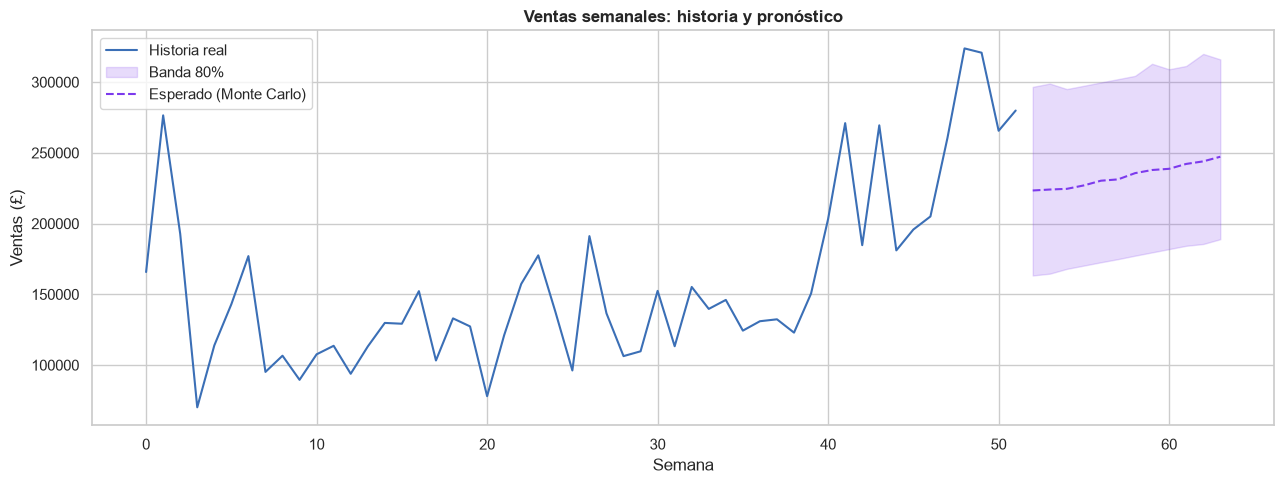

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(range(n), serie.values, color="#3B6FB6", label="Historia real")
fx = range(n, n + len(fut))
ax.fill_between(fx, fut["p10"], fut["p90"], color="#7C3AED", alpha=0.18, label="Banda 80%")
ax.plot(fx, fut["media"], color="#7C3AED", linestyle="--", label="Esperado (Monte Carlo)")
ax.set_title("Ventas semanales: historia y pronóstico", fontweight="bold")
ax.set_xlabel("Semana")
ax.set_ylabel("Ventas (£)")
ax.legend()
plt.tight_layout()
plt.show()


La línea punteada es el valor esperado y la franja sombreada el rango donde caería el 80% de los escenarios. La banda da la magnitud de la incertidumbre, algo que un pronóstico de un solo número escondería.


### La distribución de resultados

La verdadera riqueza de Monte Carlo es que entrega una distribución completa de resultados posibles, no solo un promedio. Con ella se pueden responder preguntas de probabilidad.


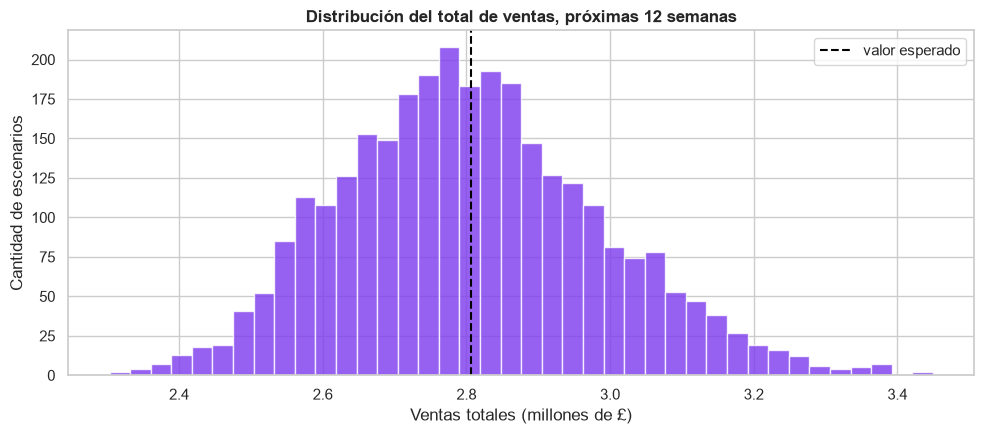

Probabilidad de superar £2.0M: 100%
Probabilidad de superar £2.5M: 97%
Probabilidad de superar £3.0M: 15%


In [18]:
totales = resultado["totales"]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(totales / 1e6, bins=40, color="#7C3AED", alpha=0.8, edgecolor="white")
ax.axvline(totales.mean() / 1e6, color="black", linestyle="--", label="valor esperado")
ax.set_title("Distribución del total de ventas, próximas 12 semanas", fontweight="bold")
ax.set_xlabel("Ventas totales (millones de £)")
ax.set_ylabel("Cantidad de escenarios")
ax.legend()
plt.tight_layout()
plt.show()

for meta in [2.0, 2.5, 3.0]:
    prob = (totales > meta * 1e6).mean() * 100
    print(f"Probabilidad de superar £{meta:.1f}M: {prob:.0f}%")


La distribución permite afirmaciones útiles para planificar, por ejemplo la probabilidad de alcanzar una meta de ventas. Es información mucho más rica que un único número.

Conviene ser honesto con las limitaciones. Como solo hay un año de datos, el pronóstico es de horizonte corto y no captura la caída posterior a la temporada navideña. Su valor no está en acertar la cifra exacta, sino en cuantificar el rango de lo plausible, que es justo lo que aporta Monte Carlo.


### Conclusión de la expansión

El análisis quedó completo. A la descripción y la segmentación originales se sumaron modelos que predicen el valor y la fuga de cada cliente, una mirada a los mercados internacionales, una medición de lealtad y un pronóstico de ventas con su incertidumbre. Las técnicas con datos simulados quedaron siempre marcadas como tales. Todo este trabajo se presenta de forma interactiva en el dashboard, donde el cliente puede explorar cada pieza y simular escenarios.
